<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/261554_TareaNER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 MArzo de 2026

Materia: Procesamiento de Lenguaje Natural

Ejercicios: Aplica CRF para el Reconocimiento de Entidades Nombradas al conjunto de datos proporcionado.

In [1]:
!pip install sklearn-crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.9 MB/s eta 0:00:00


In [28]:
import sklearn_crfsuite
from sklearn_crfsuite import metrics
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


###Instrucciones:

1.	Carga el conjunto de datos y revisa su contenido.




In [4]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Leer el archivo TXT
df = pd.read_csv('/content/drive/MyDrive/PLN/split1.mx-news.txt',
    sep='\t',                  # separador de columnas: tabulador
    encoding='utf-8',          # codificación del archivo
    on_bad_lines='skip',       # omite líneas mal formadas (p. ej. líneas vacías entre oraciones)
    skip_blank_lines=True
)

In [7]:
# Revisar contenido
print(df.head())
print(df.info())

   Sentence #         Word    Pos Tag
0  Sentence 1  Interesante    ADJ   O
1  Sentence 1         será  VLfin   O
2  Sentence 1      conocer  VLinf   O
3  Sentence 1          las    ART   O
4  Sentence 1  reflexiones     NC   O
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49318 entries, 0 to 49317
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence #  49318 non-null  object
 1   Word        49318 non-null  object
 2   Pos         49318 non-null  object
 3   Tag         49318 non-null  object
dtypes: object(4)
memory usage: 1.5+ MB
None


2.	Preprocesa los datos para generar las frases tal como las vistas en las diapositivas 19 y 20 de la presentación:


In [8]:
def agrupar_oraciones(df):
    oraciones = []

    # Asegurar filas válidas
    df = df[df["Sentence #"].astype(str).str.startswith("Sentence")]

    # Agrupar por oración
    grouped = df.groupby("Sentence #", sort=False)

    for _, grupo in grouped:
        sentence = [
            (w, p, t)
            for w, p, t in zip(grupo["Word"], grupo["Pos"], grupo["Tag"])
        ]
        oraciones.append(sentence)

    return oraciones

In [9]:
sentences = agrupar_oraciones(df)

# Mostrar la primera oración
print(sentences[0])

[('Interesante', 'ADJ', 'O'), ('será', 'VLfin', 'O'), ('conocer', 'VLinf', 'O'), ('las', 'ART', 'O'), ('reflexiones', 'NC', 'O'), ('de', 'PREP', 'O'), ('Pedro', 'NP', 'B-PER'), ('Kumamoto', 'NC', 'E-PER'), ('en', 'PREP', 'O'), ('torno', 'NC', 'O'), ('a', 'PREP', 'O'), ('este', 'DM', 'O'), ('fracaso', 'NC', 'O'), (',', 'CM', 'O'), ('por', 'PREP', 'O'), ('el', 'ART', 'O'), ('momento', 'NC', 'O'), ('lo', 'ART', 'O'), ('único', 'NC', 'O'), ('que', 'CQUE', 'O'), ('ha', 'VHfin', 'O'), ('dicho', 'QU', 'O'), ('es', 'VSfin', 'O'), ('que', 'CQUE', 'O'), ('al', 'PAL', 'O'), ('interior', 'NC', 'O'), ('de', 'PREP', 'O'), ('su', 'PPO', 'O'), ('grupo', 'NC', 'O'), ('existen', 'VLfin', 'O'), ('dos', 'CARD', 'O'), ('planteamientos', 'NC', 'O'), (',', 'CM', 'O'), ('uno', 'CARD', 'O'), ('seguir', 'VLinf', 'O'), ('por', 'PREP', 'O'), ('la', 'ART', 'O'), ('ruta', 'NC', 'O'), ('independiente', 'ADJ', 'O'), (',', 'CM', 'O'), ('el', 'ART', 'O'), ('otro', 'QU', 'O'), ('destaca', 'VLfin', 'O'), ('las', 'ART', '

3.	Genera el conjunto train con el 80% de las frases formadas y el 20% para el conjunto test.


In [21]:
# --------------------------
# Dataset de entrenamiento y prueba
# --------------------------

train_sents, test_sents = train_test_split(
    sentences,
    test_size=0.20,     # 20% para test
    random_state=42,    # reproducibilidad
    shuffle=True        # mezcla aleatoria antes de dividir
)


print(f"\nTrain : {len(train_sents)} oraciones")
print(f"Test  : {len(test_sents)}  oraciones")

# ── Separar (word, pos) de las etiquetas ─────────────────────────────────────
#   train_sentences / test_sentences → tuplas (word, pos)   ← entrada al modelo
#   train_labels    / test_labels    → lista de tags         ← salida esperada

train_sentences = [[(w, p) for w, p, _ in s] for s in train_sents]
test_sentences  = [[(w, p) for w, p, _ in s] for s in test_sents]

train_labels    = [[t for _, _, t in s] for s in train_sents]
test_labels     = [[t for _, _, t in s] for s in test_sents]

print(f"\nEjemplo train_sentences[0]: {train_sentences[0][:4]}")
print(f"Ejemplo train_labels[0]   : {train_labels[0][:4]}")




Train : 1036 oraciones
Test  : 259  oraciones

Ejemplo train_sentences[0]: [('Con', 'PREP'), ('base', 'NC'), ('en', 'PREP'), ('las', 'ART')]
Ejemplo train_labels[0]   : ['O', 'O', 'O', 'O']


4.	Aplica las métricas para evaluar el desempeño del modelo.


In [23]:
def word2features(sent, i):
    word, postag = sent[i]                      # ← tupla (word, pos)
    features = {
        'word.lower()': word.lower(),
        'postag':       postag,
        'is_title':     word.istitle(),
        'is_upper':     word.isupper(),
        'is_digit':     word.isdigit()
    }

    if i > 0:
        prev_word, prev_pos = sent[i - 1]
        features.update({
            '-1:word.lower()': prev_word.lower(),
            '-1:postag':       prev_pos
        })
    else:
        features['BOS'] = True                  # Beginning Of Sentence

    if i < len(sent) - 1:
        next_word, next_pos = sent[i + 1]
        features.update({
            '+1:word.lower()': next_word.lower(),
            '+1:postag':       next_pos
        })
    else:
        features['EOS'] = True                  # End Of Sentence

    return features


def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]


# ── Aplicar a todos los conjuntos ─────────────────────
X_train = [sent2features(s) for s in train_sentences]
y_train = train_labels

X_test  = [sent2features(s) for s in test_sentences]
y_test  = test_labels

print(f"\nFeatures del token 0, oración 0:")
print(X_train[0][0])

# --------------------------
# Entrenar modelo CRF
# --------------------------
crf = sklearn_crfsuite.CRF(
    algorithm                = 'lbfgs',
    max_iterations           = 100,
    all_possible_transitions = True
)
crf.fit(X_train, y_train)

y_pred = crf.predict(X_test)
print("\n✅ Modelo CRF entrenado y predicciones generadas.")

# --------------------------
# Métricas de desempeño
# --------------------------
labels_no_O = sorted(
    set(tag for seq in y_train for tag in seq if tag != 'O')
)

print("\n" + "="*62)
print("       MÉTRICAS DE DESEMPEÑO — NER (CRF)")
print("="*62)
report = metrics.flat_classification_report(
    y_test, y_pred,
    labels = labels_no_O,
    digits = 4
)
print(report)

accuracy = metrics.flat_accuracy_score(y_test, y_pred)
print(f"  Exactitud global (incluye etiqueta 'O') : {accuracy:.4f}")


Features del token 0, oración 0:
{'word.lower()': 'con', 'postag': 'PREP', 'is_title': True, 'is_upper': False, 'is_digit': False, 'BOS': True, '+1:word.lower()': 'base', '+1:postag': 'NC'}

✅ Modelo CRF entrenado y predicciones generadas.

       MÉTRICAS DE DESEMPEÑO — NER (CRF)
              precision    recall  f1-score   support

       B-ADD     1.0000    0.8571    0.9231         7
       B-AGE     1.0000    0.8000    0.8889         5
       B-DAT     0.9537    0.9450    0.9493       109
       B-DOC     1.0000    0.2857    0.4444        14
       B-EVT     1.0000    0.4348    0.6061        23
       B-FAC     0.8571    0.4286    0.5714        14
       B-GPE     0.8333    0.7407    0.7843        27
       B-LOC     1.0000    0.2500    0.4000         4
       B-MNY     1.0000    0.7692    0.8696        13
       B-ORG     0.7802    0.8875    0.8304        80
       B-PER     0.8684    0.8980    0.8829       147
       B-PEX     1.0000    1.0000    1.0000        13
       B-PRC  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

5.	Muestra la matriz de confusión.


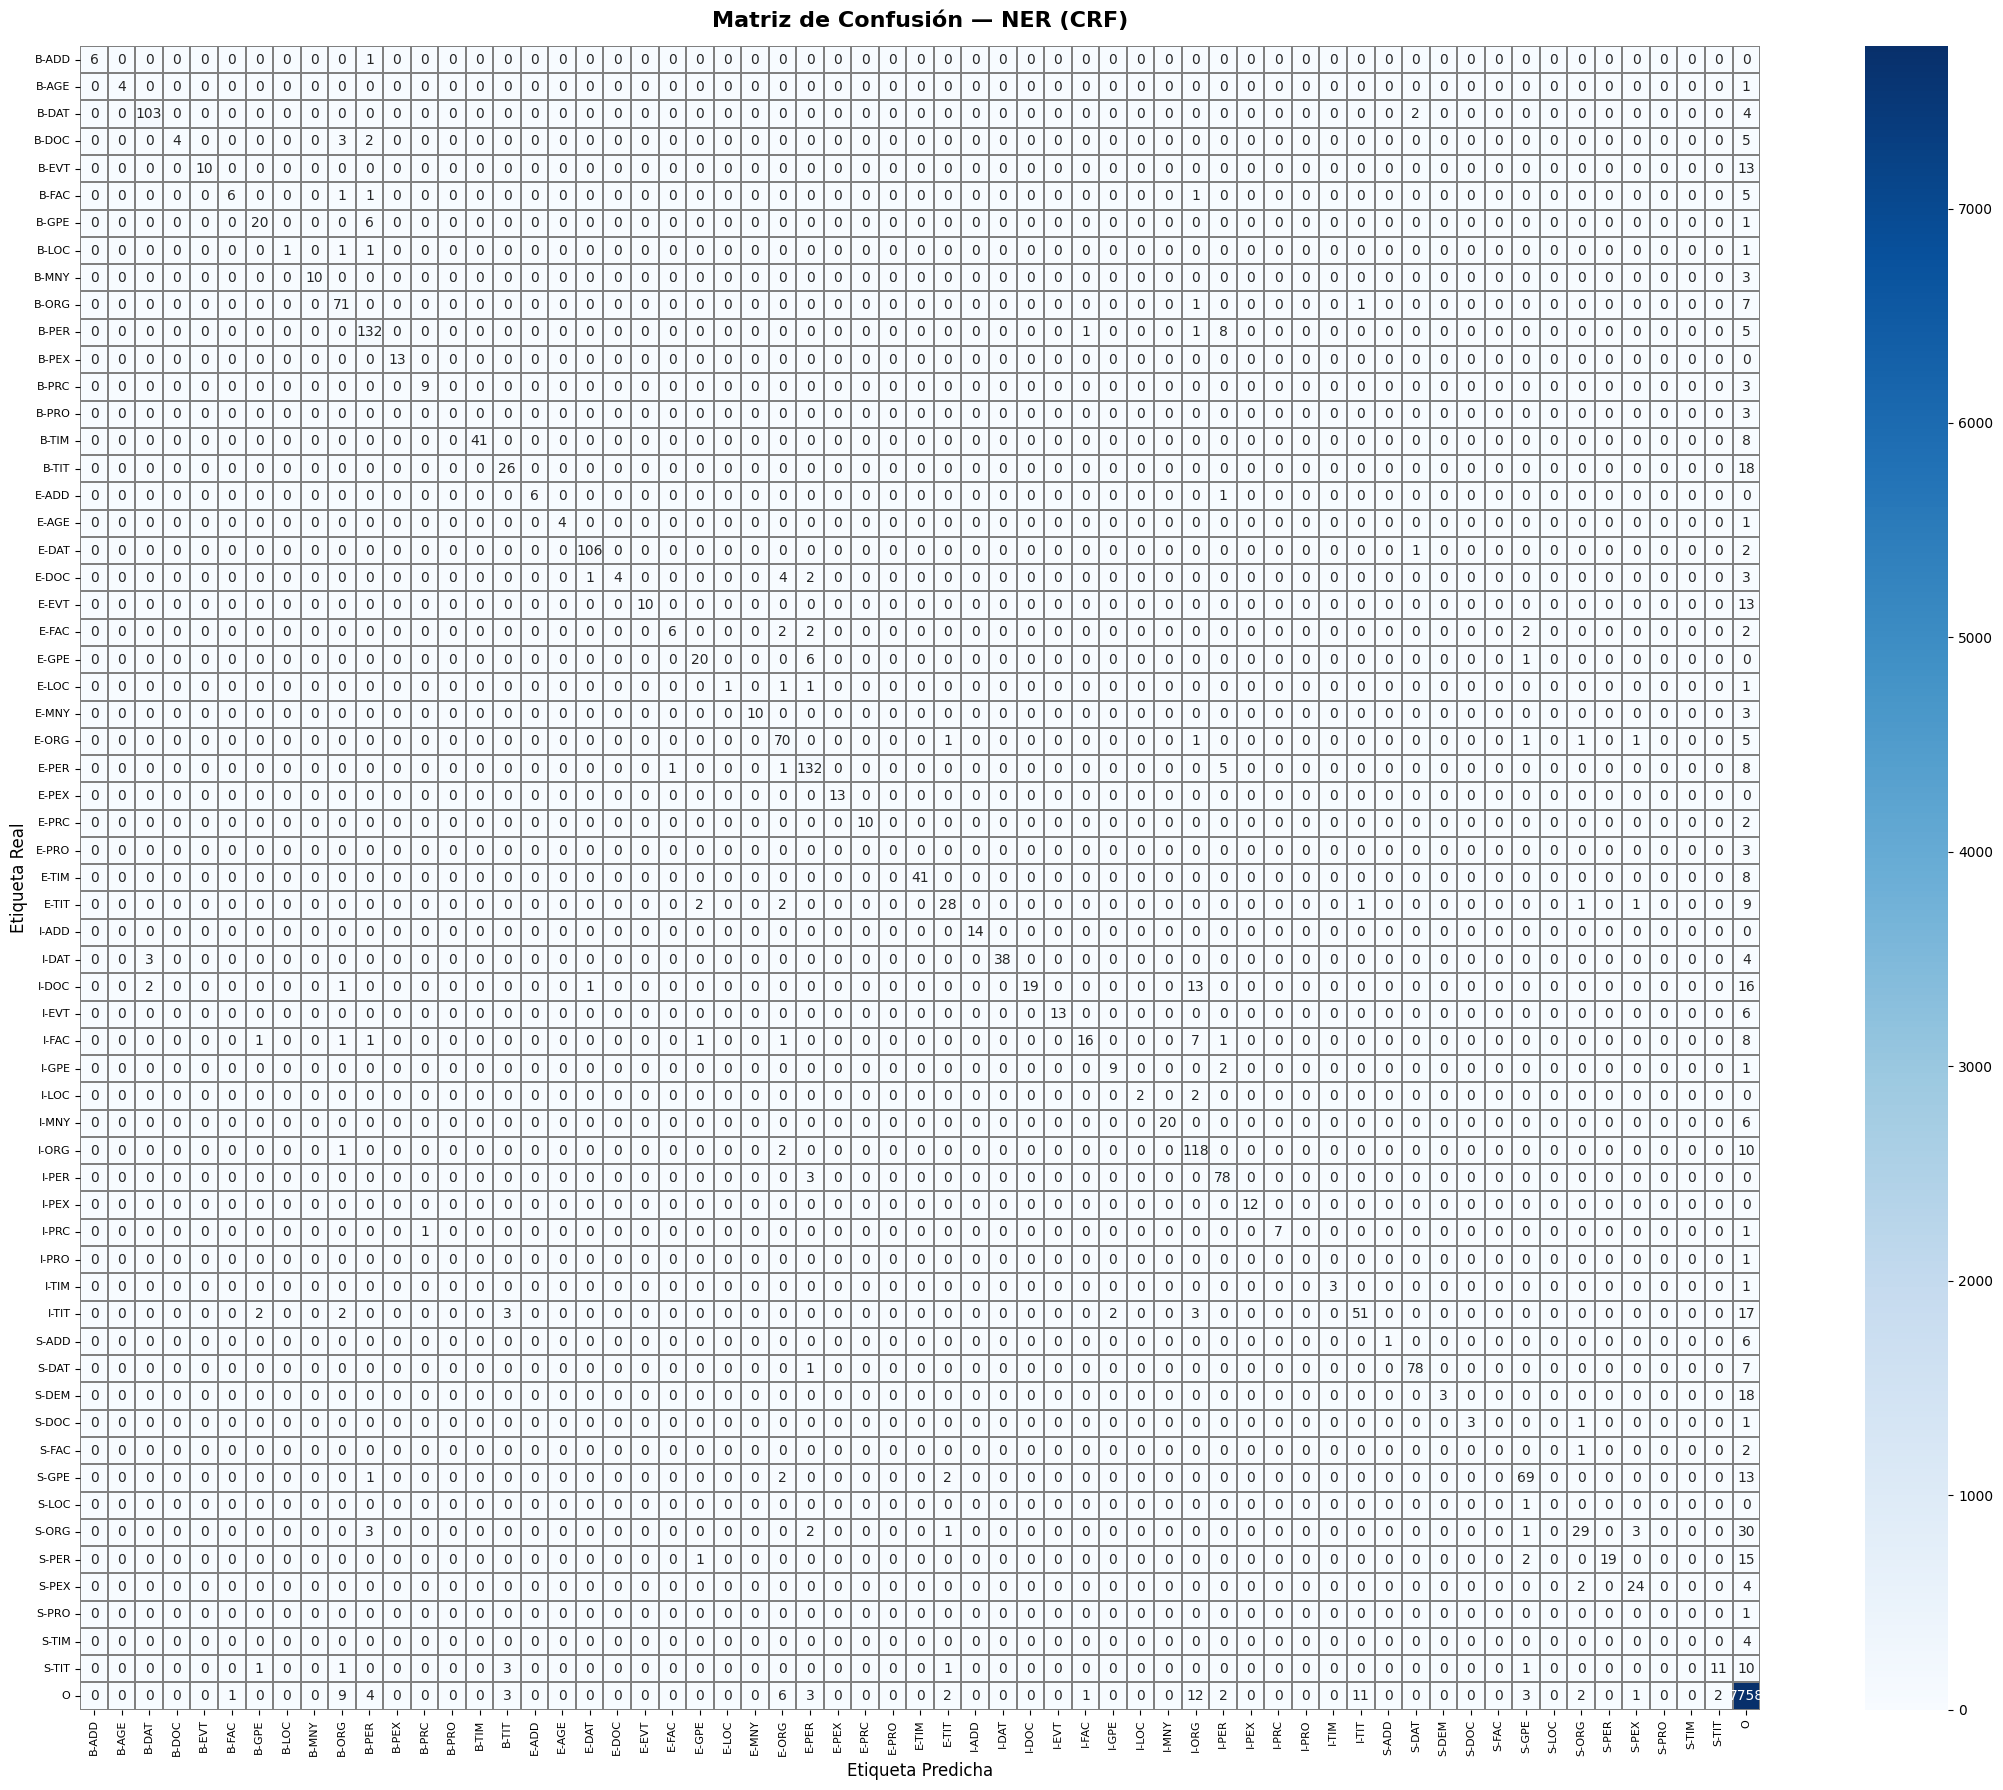

In [29]:
# --------------------------
# Matriz de confusión
# --------------------------
# Aplanar listas de listas → listas planas
y_test_flat = [t for seq in y_test  for t in seq]
y_pred_flat = [t for seq in y_pred  for t in seq]

# Etiquetas ordenadas, 'O' al final para mejor legibilidad
all_labels = sorted(set(y_test_flat) - {'O'}) + ['O']

cm = confusion_matrix(y_test_flat, y_pred_flat, labels=all_labels)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = all_labels,
    yticklabels = all_labels,
    ax          = ax,
    linewidths  = 0.3,
    linecolor   = 'grey'
)
ax.set_title('Matriz de Confusión — NER (CRF)',
             fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)
ax.set_ylabel('Etiqueta Real',     fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_ner.png', dpi=150, bbox_inches='tight')
plt.show()


6.	Identifica y menciona cuál fue la etiqueta NER que consideres fue en la que CRF tuvo el más bajo desempeño.

La etiqueta S-DEM (Gentilicio de token único, ej: "mexicano", "estadounidense", "venezolano") fue la de peor desempeño significativo del modelo CRF con un F1-score de 0.2500, causado por un Recall extremadamente bajo de 0.1429: el modelo casi nunca reconoce un gentilicio como entidad nombrada, confundiéndolo con la clase O.


La etiqueta S-ADD (dirección de un solo token) obtuvo un F1-score de 0.2500, el más bajo junto con S-DEM. Su principal problema es el Recall de 0.1429: el modelo prácticamente ignora las direcciones, reconociendo solo 1 de las 7 presentes en el test. Esto se debe a la escasez de ejemplos de entrenamiento, la alta variabilidad léxica de las direcciones y la falta de features especializados para este tipo de entidad.